In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 14,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
})
PALETTE = ["#2D6A4F", "#40916C", "#52B788", "#74C69D", "#95D5B2"]
ACCENT  = "#2D6A4F"

# ── DB Connection ──────────────────────────────────────────────
load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
print("✓ Connected to OrdersPlus database")

✓ Connected to OrdersPlus database


In [2]:
query = """
SELECT
    COUNT(DISTINCT o.order_id)        AS total_orders,
    COUNT(DISTINCT o.customer_id)     AS total_customers,
    ROUND(SUM(p.payment_value), 2)    AS total_revenue,
    ROUND(AVG(p.payment_value), 2)    AS avg_order_value,
    SUM(o.is_late_delivery)           AS late_orders,
    ROUND(SUM(o.is_late_delivery) * 100.0 / COUNT(o.order_id), 2) AS late_pct
FROM orders o
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
"""
health = pd.read_sql(query, engine)

print("=" * 45)
print("   OrdersPlus — Business Health Summary")
print("=" * 45)
print(f"  Total Orders     : {health['total_orders'][0]:>10,}")
print(f"  Total Customers  : {health['total_customers'][0]:>10,}")
print(f"  Total Revenue    : R$ {health['total_revenue'][0]:>12,.2f}")
print(f"  Avg Order Value  : R$ {health['avg_order_value'][0]:>12,.2f}")
print(f"  Late Orders      : {health['late_orders'][0]:>10,} ({health['late_pct'][0]}%)")
print("=" * 45)

   OrdersPlus — Business Health Summary
  Total Orders     :     96,477
  Total Customers  :     96,477
  Total Revenue    : R$ 15,422,461.77
  Avg Order Value  : R$       153.07
  Late Orders      :    8,125.0 (8.06%)


FileNotFoundError: [Errno 2] No such file or directory: 'docs/02_top_categories.png'

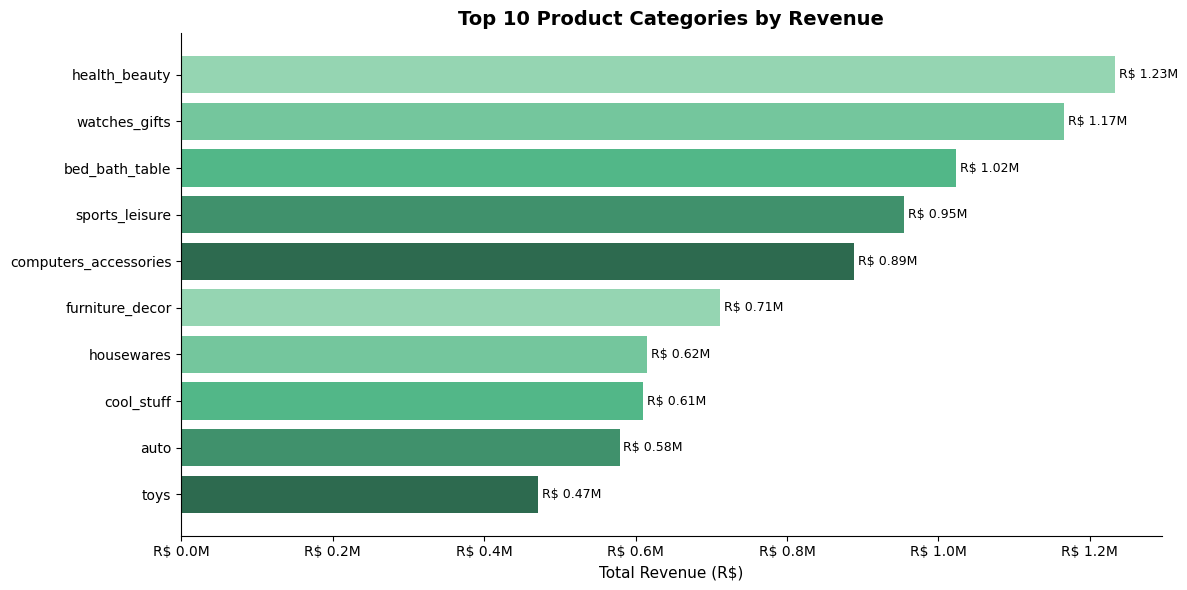

In [5]:
query = """
SELECT
    COALESCE(ct.product_category_name_english,
             pr.product_category_name)          AS category,
    COUNT(DISTINCT oi.order_id)                  AS total_orders,
    ROUND(SUM(oi.price), 2)                      AS total_revenue
FROM order_items oi
JOIN products pr ON oi.product_id = pr.product_id
JOIN orders o    ON oi.order_id   = o.order_id
LEFT JOIN category_translation ct
       ON pr.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10
"""
cats = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cats["category"][::-1], cats["total_revenue"][::-1],
               color=PALETTE * 2)
ax.set_title("Top 10 Product Categories by Revenue")
ax.set_xlabel("Total Revenue (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"R$ {x/1_000_000:.1f}M"))

for bar, val in zip(bars, cats["total_revenue"][::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"R$ {val/1_000_000:.2f}M", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("docs/02_top_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → docs/02_top_categories.png")

In [6]:
import os
os.chdir(r"E:\Projects\OrdersPlus")
print("Working directory:", os.getcwd())

Working directory: E:\Projects\OrdersPlus


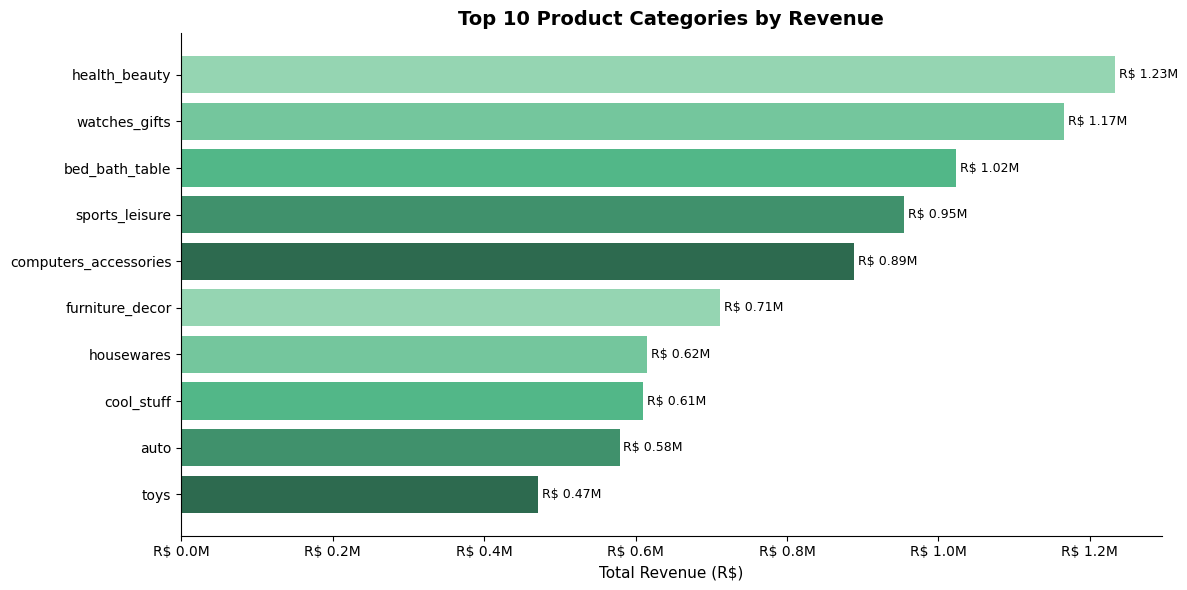

✓ Saved → docs/02_top_categories.png


In [7]:
query = """
SELECT
    COALESCE(ct.product_category_name_english,
             pr.product_category_name)          AS category,
    COUNT(DISTINCT oi.order_id)                  AS total_orders,
    ROUND(SUM(oi.price), 2)                      AS total_revenue
FROM order_items oi
JOIN products pr ON oi.product_id = pr.product_id
JOIN orders o    ON oi.order_id   = o.order_id
LEFT JOIN category_translation ct
       ON pr.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10
"""
cats = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cats["category"][::-1], cats["total_revenue"][::-1],
               color=PALETTE * 2)
ax.set_title("Top 10 Product Categories by Revenue")
ax.set_xlabel("Total Revenue (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"R$ {x/1_000_000:.1f}M"))

for bar, val in zip(bars, cats["total_revenue"][::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"R$ {val/1_000_000:.2f}M", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("docs/02_top_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → docs/02_top_categories.png")

In [8]:
query = """
SELECT
    c.customer_state                         AS state,
    COUNT(o.order_id)                         AS total_orders,
    SUM(o.is_late_delivery)                   AS late_orders,
    ROUND(SUM(o.is_late_delivery) * 100.0
          / COUNT(o.order_id), 2)             AS late_pct,
    ROUND(AVG(o.delivery_days), 1)            AS avg_delivery_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
HAVING COUNT(o.order_id) > 100
ORDER BY late_pct DESC
"""
late = pd.read_sql(query, engine)

print(late[["state","total_orders","late_orders","late_pct","avg_delivery_days"]].to_string(index=False))

state  total_orders  late_orders  late_pct  avg_delivery_days
   AL           397         95.0     23.93               24.0
   MA           717        141.0     19.67               21.1
   PI           476         76.0     15.97               19.0
   CE          1279        196.0     15.32               20.8
   SE           335         51.0     15.22               21.0
   BA          3256        457.0     14.04               18.9
   RJ         12350       1664.0     13.47               14.8
   TO           274         35.0     12.77               17.2
   PA           946        117.0     12.37               23.3
   ES          1995        244.0     12.23               15.3
   MS           701         81.0     11.55               15.2
   PB           517         57.0     11.03               20.0
   PE          1593        172.0     10.80               18.0
   RN           474         51.0     10.76               18.8
   SC          3546        346.0      9.76               14.5
   GO   

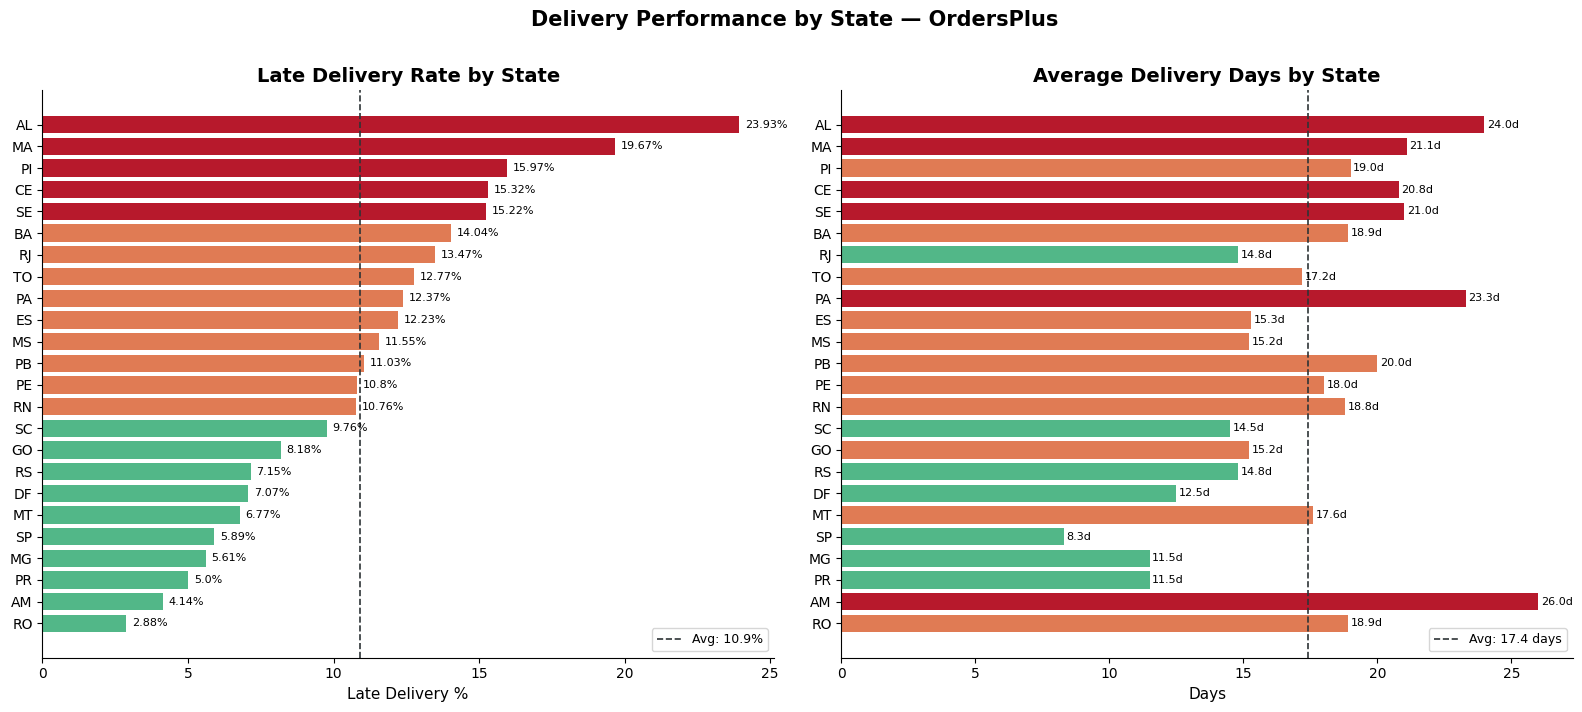

✓ Saved → docs/03_delivery_by_state.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart 1: Late % by state ──────────────────────────────────
colors = ["#B7192C" if x > 15 else "#E07B54" if x > 10 else "#52B788"
          for x in late["late_pct"]]

axes[0].barh(late["state"][::-1], late["late_pct"][::-1], color=colors[::-1])
axes[0].axvline(late["late_pct"].mean(), color="#2D3436", linestyle="--",
                linewidth=1.2, label=f"Avg: {late['late_pct'].mean():.1f}%")
axes[0].set_title("Late Delivery Rate by State")
axes[0].set_xlabel("Late Delivery %")
axes[0].legend(fontsize=9)

for i, (val, state) in enumerate(zip(late["late_pct"][::-1],
                                      late["state"][::-1])):
    axes[0].text(val + 0.2, i, f"{val}%", va="center", fontsize=8)

# ── Chart 2: Avg delivery days ────────────────────────────────
colors2 = ["#B7192C" if x > 20 else "#E07B54" if x > 15 else "#52B788"
           for x in late["avg_delivery_days"]]

axes[1].barh(late["state"][::-1], late["avg_delivery_days"][::-1],
             color=colors2[::-1])
axes[1].axvline(late["avg_delivery_days"].mean(), color="#2D3436",
                linestyle="--", linewidth=1.2,
                label=f"Avg: {late['avg_delivery_days'].mean():.1f} days")
axes[1].set_title("Average Delivery Days by State")
axes[1].set_xlabel("Days")
axes[1].legend(fontsize=9)

for i, val in enumerate(late["avg_delivery_days"][::-1]):
    axes[1].text(val + 0.1, i, f"{val}d", va="center", fontsize=8)

plt.suptitle("Delivery Performance by State — OrdersPlus",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("docs/03_delivery_by_state.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → docs/03_delivery_by_state.png")

In [10]:
query = """
SELECT
    CASE WHEN o.is_late_delivery = 1
         THEN 'Late' ELSE 'On Time' END    AS delivery_status,
    COUNT(o.order_id)                       AS total_orders,
    ROUND(AVG(r.review_score), 3)           AS avg_review_score,
    SUM(CASE WHEN r.review_score = 1 THEN 1 ELSE 0 END) AS score_1,
    SUM(CASE WHEN r.review_score = 2 THEN 1 ELSE 0 END) AS score_2,
    SUM(CASE WHEN r.review_score = 3 THEN 1 ELSE 0 END) AS score_3,
    SUM(CASE WHEN r.review_score = 4 THEN 1 ELSE 0 END) AS score_4,
    SUM(CASE WHEN r.review_score = 5 THEN 1 ELSE 0 END) AS score_5
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY o.is_late_delivery
ORDER BY o.is_late_delivery
"""
review_late = pd.read_sql(query, engine)
print(review_late.to_string(index=False))

delivery_status  total_orders  avg_review_score  score_1  score_2  score_3  score_4  score_5
        On Time         88661             4.294   5852.0   2335.0   7086.0  18033.0  55355.0
           Late          7700             2.566   3554.0    606.0    875.0    954.0   1711.0


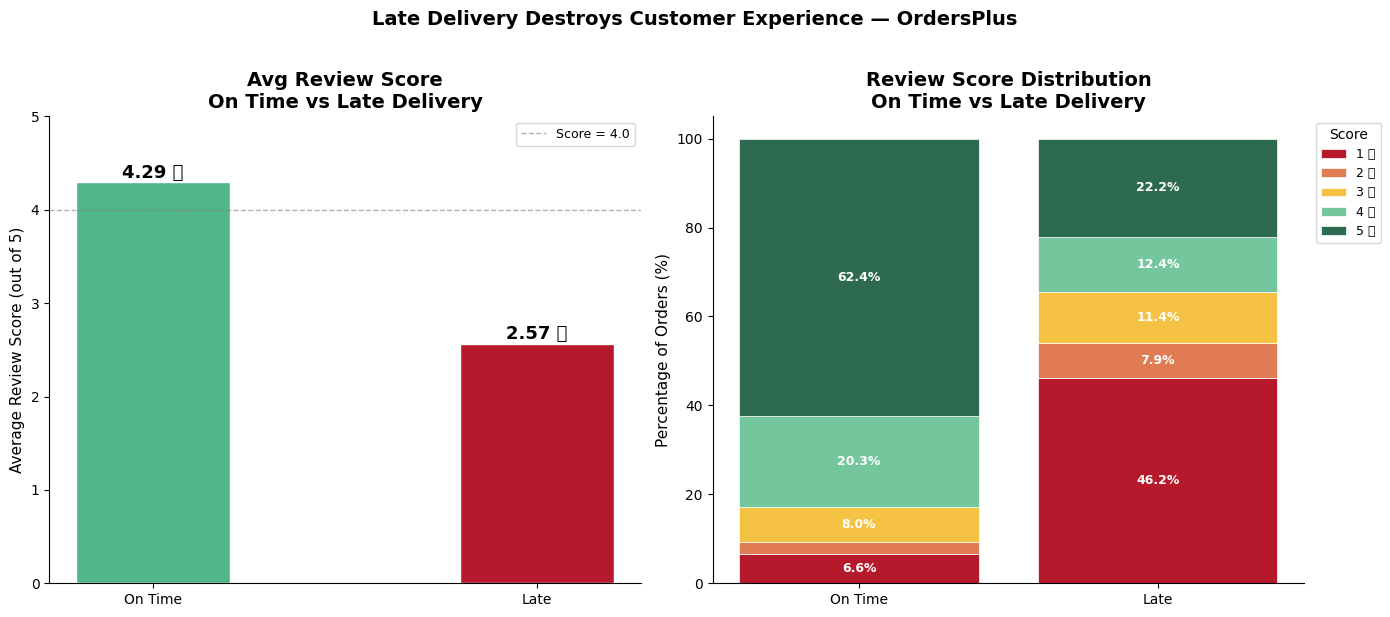

✓ Saved → docs/04_review_vs_delivery.png

  Key insight: Late orders are 2.57★ vs 4.29★ on time
  Late orders with 1★ : 46.2%
  On time orders with 1★ : 6.6%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Avg review score comparison ─────────────────────
bar_colors = ["#52B788", "#B7192C"]
bars = axes[0].bar(review_late["delivery_status"],
                   review_late["avg_review_score"],
                   color=bar_colors, width=0.4, edgecolor="white")

axes[0].set_ylim(0, 5)
axes[0].set_title("Avg Review Score\nOn Time vs Late Delivery")
axes[0].set_ylabel("Average Review Score (out of 5)")
axes[0].axhline(y=4.0, color="gray", linestyle="--",
                linewidth=1, alpha=0.6, label="Score = 4.0")
axes[0].legend(fontsize=9)

for bar, val in zip(bars, review_late["avg_review_score"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"{val:.2f} ⭐", ha="center",
                 fontsize=13, fontweight="bold")

# ── Chart 2: Score distribution stacked bar ───────────────────
score_cols  = ["score_1", "score_2", "score_3", "score_4", "score_5"]
score_labels = ["1 ⭐", "2 ⭐", "3 ⭐", "4 ⭐", "5 ⭐"]
score_colors = ["#B7192C", "#E07B54", "#F6C243", "#74C69D", "#2D6A4F"]

# Convert to percentages
totals = review_late["total_orders"].values
pct_data = {}
for col in score_cols:
    pct_data[col] = review_late[col].values / totals * 100

bottom = np.zeros(2)
for col, label, color in zip(score_cols, score_labels, score_colors):
    vals = pct_data[col]
    bars2 = axes[1].bar(review_late["delivery_status"], vals,
                        bottom=bottom, label=label,
                        color=color, edgecolor="white", linewidth=0.5)
    for bar, val, bot in zip(bars2, vals, bottom):
        if val > 4:
            axes[1].text(bar.get_x() + bar.get_width()/2,
                         bot + val/2,
                         f"{val:.1f}%", ha="center",
                         va="center", fontsize=9,
                         color="white", fontweight="bold")
    bottom += vals

axes[1].set_title("Review Score Distribution\nOn Time vs Late Delivery")
axes[1].set_ylabel("Percentage of Orders (%)")
axes[1].set_ylim(0, 105)
axes[1].legend(title="Score", bbox_to_anchor=(1.01, 1),
               loc="upper left", fontsize=9)

plt.suptitle("Late Delivery Destroys Customer Experience — OrdersPlus",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("docs/04_review_vs_delivery.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → docs/04_review_vs_delivery.png")
print(f"\n  Key insight: Late orders are {review_late['avg_review_score'][1]:.2f}★ vs {review_late['avg_review_score'][0]:.2f}★ on time")
print(f"  Late orders with 1★ : {review_late['score_1'][1]/review_late['total_orders'][1]*100:.1f}%")
print(f"  On time orders with 1★ : {review_late['score_1'][0]/review_late['total_orders'][0]*100:.1f}%")

In [12]:
query = """
WITH rfm_base AS (
    SELECT
        c.customer_unique_id,
        MAX(DATE(o.order_purchase_timestamp))  AS last_purchase_date,
        COUNT(DISTINCT o.order_id)             AS frequency,
        ROUND(SUM(p.payment_value), 2)         AS monetary
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN payments p  ON o.order_id    = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
rfm_scores AS (
    SELECT *,
        DATEDIFF('2018-10-01', last_purchase_date) AS recency_days,
        NTILE(5) OVER (ORDER BY DATEDIFF('2018-10-01',
                       last_purchase_date) ASC)    AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC)     AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC)      AS m_score
    FROM rfm_base
)
SELECT *,
    (r_score + f_score + m_score) AS rfm_total,
    CASE
        WHEN (r_score + f_score + m_score) >= 13 THEN 'Champions'
        WHEN (r_score + f_score + m_score) >= 10 THEN 'Loyal Customers'
        WHEN r_score >= 4 AND (f_score + m_score) < 6 THEN 'Promising'
        WHEN r_score <= 2 AND (f_score + m_score) >= 8 THEN 'At Risk'
        WHEN r_score <= 2 THEN 'Lost'
        ELSE 'Needs Attention'
    END AS customer_segment
FROM rfm_scores
"""
rfm = pd.read_sql(query, engine)

seg_summary = rfm.groupby("customer_segment").agg(
    customer_count = ("customer_unique_id", "count"),
    avg_monetary   = ("monetary", "mean"),
    total_revenue  = ("monetary", "sum"),
    avg_recency    = ("recency_days", "mean"),
    avg_frequency  = ("frequency", "mean")
).round(2).sort_values("total_revenue", ascending=False)

print(seg_summary.to_string())

                  customer_count  avg_monetary  total_revenue  avg_recency  avg_frequency
customer_segment                                                                         
Loyal Customers            36312        260.42     9456284.98       292.40           1.05
Lost                       23047         95.03     2190217.29       108.75           1.00
Promising                  22168         72.50     1607262.59       430.34           1.00
At Risk                     3009        439.32     1321913.36        74.74           1.03
Needs Attention             7662         55.45      424847.35       252.39           1.00
Champions                   1159        364.05      421936.20       369.46           2.11


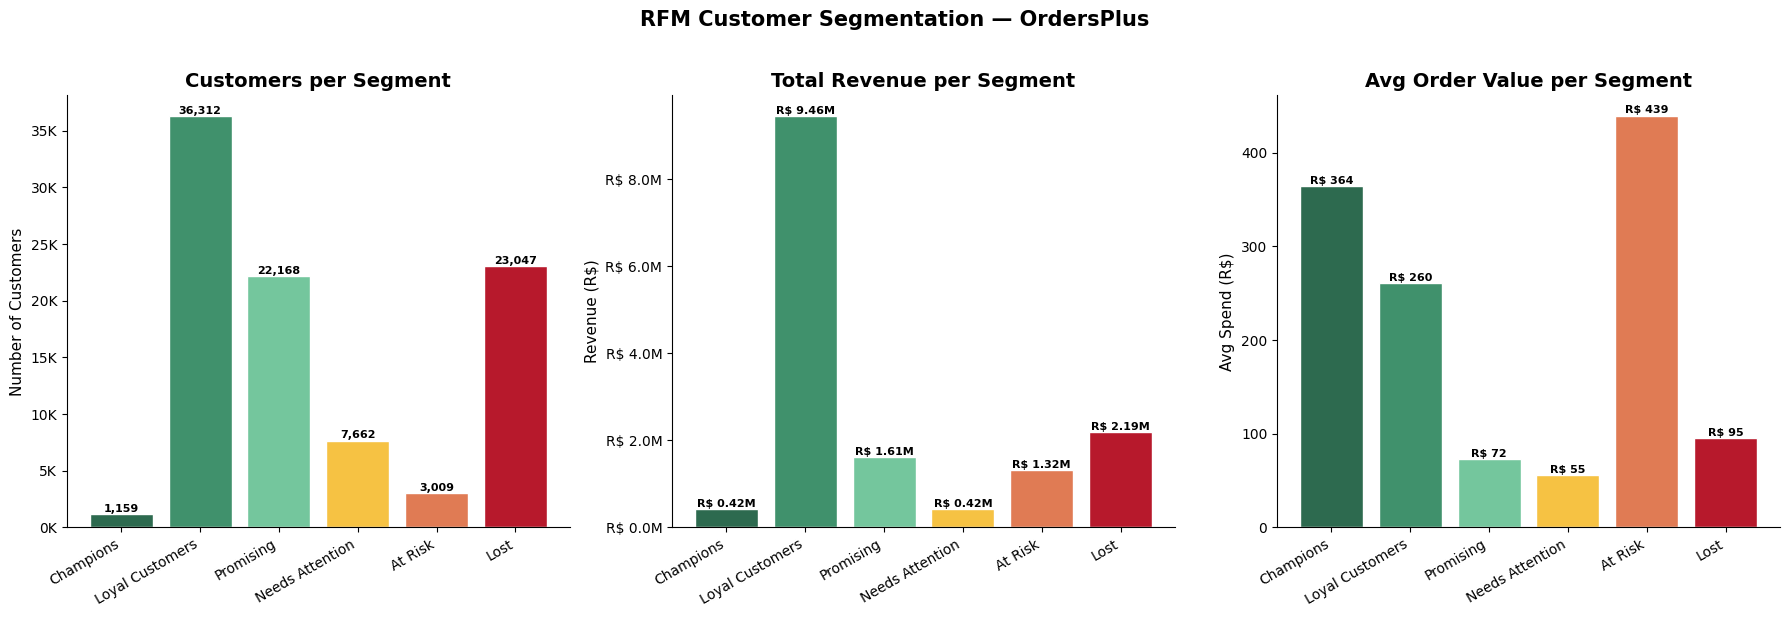

✓ Saved → docs/05_rfm_segments.png

  At Risk customers  : 3,009 customers worth saving
  Lost customers     : 23,047 customers already gone
  Champions revenue  : R$ 421,936


In [13]:
seg_order = ["Champions", "Loyal Customers", "Promising",
             "Needs Attention", "At Risk", "Lost"]
seg_colors = {
    "Champions"       : "#2D6A4F",
    "Loyal Customers" : "#40916C",
    "Promising"       : "#74C69D",
    "Needs Attention" : "#F6C243",
    "At Risk"         : "#E07B54",
    "Lost"            : "#B7192C",
}

seg_plot = seg_summary.reindex(seg_order)
colors   = [seg_colors[s] for s in seg_order]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Chart 1: Customer count per segment ──────────────────────
axes[0].bar(seg_order, seg_plot["customer_count"],
            color=colors, edgecolor="white")
axes[0].set_title("Customers per Segment")
axes[0].set_ylabel("Number of Customers")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1000:.0f}K"))
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")
for i, val in enumerate(seg_plot["customer_count"]):
    axes[0].text(i, val + 200, f"{val:,}",
                 ha="center", fontsize=8, fontweight="bold")

# ── Chart 2: Total revenue per segment ───────────────────────
axes[1].bar(seg_order, seg_plot["total_revenue"],
            color=colors, edgecolor="white")
axes[1].set_title("Total Revenue per Segment")
axes[1].set_ylabel("Revenue (R$)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"R$ {x/1_000_000:.1f}M"))
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
for i, val in enumerate(seg_plot["total_revenue"]):
    axes[1].text(i, val + 50000, f"R$ {val/1_000_000:.2f}M",
                 ha="center", fontsize=8, fontweight="bold")

# ── Chart 3: Avg order value per segment ─────────────────────
axes[2].bar(seg_order, seg_plot["avg_monetary"],
            color=colors, edgecolor="white")
axes[2].set_title("Avg Order Value per Segment")
axes[2].set_ylabel("Avg Spend (R$)")
plt.setp(axes[2].get_xticklabels(), rotation=30, ha="right")
for i, val in enumerate(seg_plot["avg_monetary"]):
    axes[2].text(i, val + 3, f"R$ {val:.0f}",
                 ha="center", fontsize=8, fontweight="bold")

plt.suptitle("RFM Customer Segmentation — OrdersPlus",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("docs/05_rfm_segments.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → docs/05_rfm_segments.png")
print(f"\n  At Risk customers  : {seg_summary.loc['At Risk','customer_count']:,} customers worth saving")
print(f"  Lost customers     : {seg_summary.loc['Lost','customer_count']:,} customers already gone")
print(f"  Champions revenue  : R$ {seg_summary.loc['Champions','total_revenue']:,.0f}")

In [14]:
query = """
SELECT
    payment_type,
    COUNT(DISTINCT order_id)                     AS total_orders,
    ROUND(SUM(payment_value), 2)                 AS total_revenue,
    ROUND(AVG(payment_value), 2)                 AS avg_payment,
    ROUND(AVG(payment_installments), 2)          AS avg_installments,
    ROUND(SUM(payment_value) * 100.0 /
          SUM(SUM(payment_value)) OVER (), 2)    AS revenue_share_pct
FROM payments
GROUP BY payment_type
ORDER BY total_revenue DESC
"""
payments_df = pd.read_sql(query, engine)
print(payments_df.to_string(index=False))

payment_type  total_orders  total_revenue  avg_payment  avg_installments  revenue_share_pct
 credit_card         76505    12542084.19       163.32              3.51              78.34
      boleto         19784     2869361.27       145.03              1.00              17.92
     voucher          3866      379436.87        65.70              1.00               2.37
  debit_card          1528      217989.79       142.57              1.00               1.36
 not_defined             3           0.00         0.00              1.00               0.00


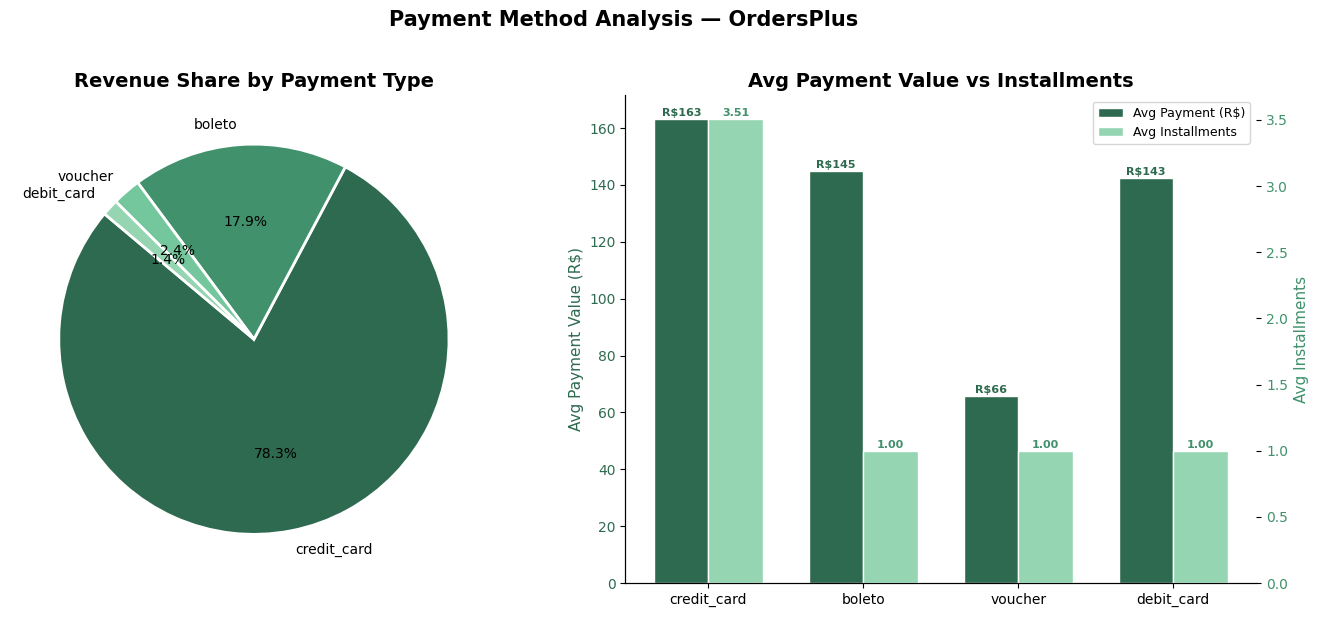

✓ Saved → docs/06_payment_analysis.png


In [15]:
# Remove not_defined
pay = payments_df[payments_df["payment_type"] != "not_defined"].copy()
pay_colors = ["#2D6A4F", "#40916C", "#74C69D", "#95D5B2"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Revenue share pie ────────────────────────────────
axes[0].pie(
    pay["revenue_share_pct"],
    labels=pay["payment_type"],
    autopct="%1.1f%%",
    colors=pay_colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Revenue Share by Payment Type")

# ── Chart 2: Avg payment vs avg installments ──────────────────
x = np.arange(len(pay))
width = 0.35

bars1 = axes[1].bar(x - width/2, pay["avg_payment"],
                    width, label="Avg Payment (R$)",
                    color="#2D6A4F", edgecolor="white")
axes[1].set_ylabel("Avg Payment Value (R$)", color="#2D6A4F")
axes[1].tick_params(axis="y", labelcolor="#2D6A4F")

ax2 = axes[1].twinx()
bars2 = ax2.bar(x + width/2, pay["avg_installments"],
                width, label="Avg Installments",
                color="#95D5B2", edgecolor="white")
ax2.set_ylabel("Avg Installments", color="#40916C")
ax2.tick_params(axis="y", labelcolor="#40916C")
ax2.spines["top"].set_visible(False)

axes[1].set_xticks(x)
axes[1].set_xticklabels(pay["payment_type"])
axes[1].set_title("Avg Payment Value vs Installments")
axes[1].spines["top"].set_visible(False)

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"R${bar.get_height():.0f}",
                 ha="center", fontsize=8, fontweight="bold",
                 color="#2D6A4F")

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{bar.get_height():.2f}",
             ha="center", fontsize=8, fontweight="bold",
             color="#40916C")

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2,
               loc="upper right", fontsize=9)

plt.suptitle("Payment Method Analysis — OrdersPlus",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("docs/06_payment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → docs/06_payment_analysis.png")

In [18]:
query = """
WITH first_orders AS (
    SELECT
        c.customer_unique_id,
        MIN(DATE_FORMAT(o.order_purchase_timestamp, '%%Y-%%m')) AS cohort_month
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
order_months AS (
    SELECT
        c.customer_unique_id,
        DATE_FORMAT(o.order_purchase_timestamp, '%%Y-%%m') AS order_month
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id,
             DATE_FORMAT(o.order_purchase_timestamp, '%%Y-%%m')
)
SELECT
    f.cohort_month,
    COUNT(DISTINCT f.customer_unique_id)            AS cohort_size,
    COUNT(DISTINCT CASE WHEN om.order_month >
          f.cohort_month THEN f.customer_unique_id
          END)                                      AS returned_customers,
    ROUND(COUNT(DISTINCT CASE WHEN om.order_month >
          f.cohort_month THEN f.customer_unique_id
          END) * 100.0 /
          COUNT(DISTINCT f.customer_unique_id), 2) AS retention_pct
FROM first_orders f
LEFT JOIN order_months om
       ON f.customer_unique_id = om.customer_unique_id
GROUP BY f.cohort_month
ORDER BY f.cohort_month
"""
cohort = pd.read_sql(query, engine)
cohort = cohort[cohort["cohort_month"] < "2018-08"]
print(cohort.to_string(index=False))

cohort_month  cohort_size  returned_customers  retention_pct
     2016-09            1                   0           0.00
     2016-10          262                   9           3.44
     2016-12            1                   1         100.00
     2017-01          717                  30           4.18
     2017-02         1628                  46           2.83
     2017-03         2503                  86           3.44
     2017-04         2256                  77           3.41
     2017-05         3451                 122           3.54
     2017-06         3037                 109           3.59
     2017-07         3752                 116           3.09
     2017-08         4057                 129           3.18
     2017-09         4004                 120           3.00
     2017-10         4328                 108           2.50
     2017-11         7060                 133           1.88
     2017-12         5338                  87           1.63
     2018-01         684

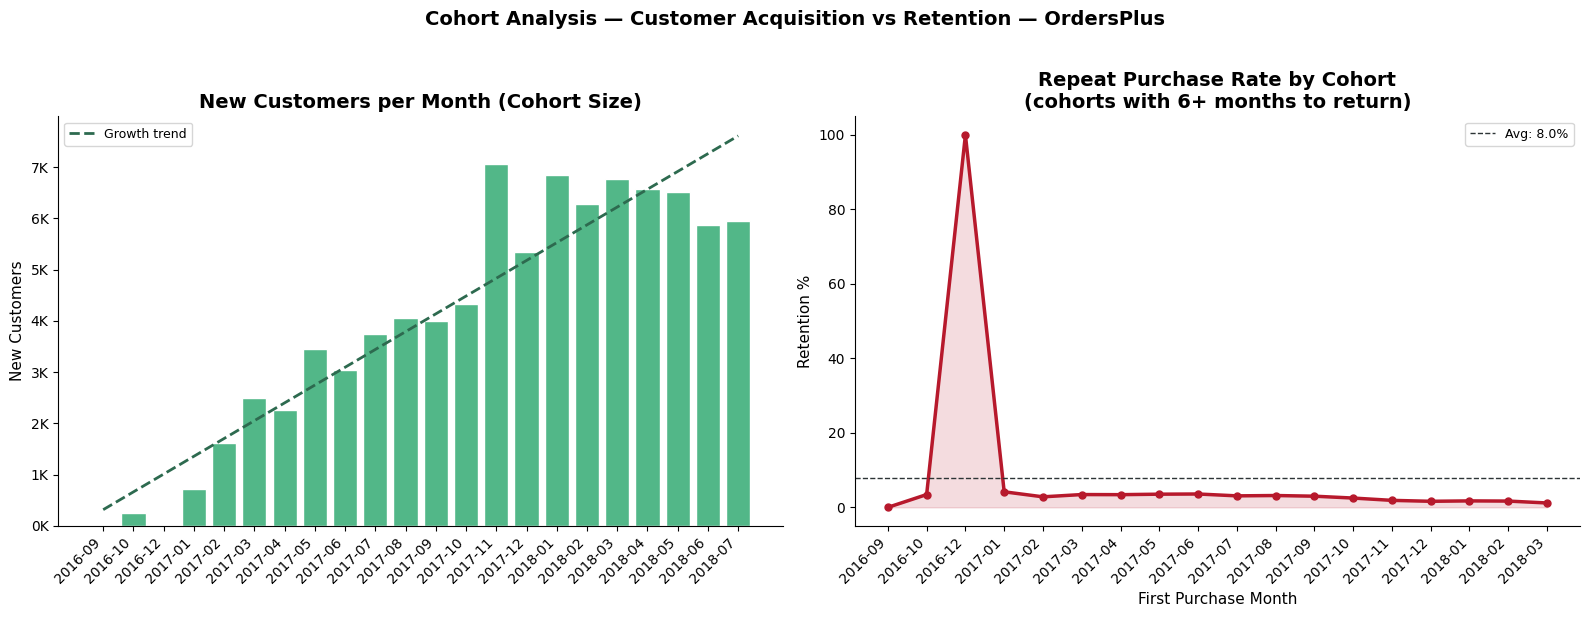

✓ Saved → docs/07_cohort_retention.png

  Avg retention rate     : 8.02%
  Meaning                : 92.0% of customers never return
  Peak cohort size       : 7,060 (2017-11)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Cohort size over time ────────────────────────────
axes[0].bar(cohort["cohort_month"], cohort["cohort_size"],
            color="#52B788", edgecolor="white")
axes[0].set_title("New Customers per Month (Cohort Size)")
axes[0].set_ylabel("New Customers")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1000:.0f}K"))
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

# growth trend line
z = np.polyfit(range(len(cohort)), cohort["cohort_size"], 1)
p = np.poly1d(z)
axes[0].plot(cohort["cohort_month"], p(range(len(cohort))),
             color="#2D6A4F", linewidth=2, linestyle="--",
             label="Growth trend")
axes[0].legend(fontsize=9)

# ── Chart 2: Retention % over time ───────────────────────────
# Only plot cohorts with enough time to return (before 2018-04)
cohort_stable = cohort[cohort["cohort_month"] < "2018-04"]

axes[1].plot(cohort_stable["cohort_month"],
             cohort_stable["retention_pct"],
             color="#B7192C", linewidth=2.5,
             marker="o", markersize=5)
axes[1].fill_between(cohort_stable["cohort_month"],
                     cohort_stable["retention_pct"],
                     alpha=0.15, color="#B7192C")
axes[1].set_title("Repeat Purchase Rate by Cohort\n(cohorts with 6+ months to return)")
axes[1].set_ylabel("Retention %")
axes[1].set_xlabel("First Purchase Month")
axes[1].axhline(cohort_stable["retention_pct"].mean(),
                color="#2D3436", linestyle="--", linewidth=1,
                label=f"Avg: {cohort_stable['retention_pct'].mean():.1f}%")
axes[1].legend(fontsize=9)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Cohort Analysis — Customer Acquisition vs Retention — OrdersPlus",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("docs/07_cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

avg_ret = cohort_stable["retention_pct"].mean()
print("✓ Saved → docs/07_cohort_retention.png")
print(f"\n  Avg retention rate     : {avg_ret:.2f}%")
print(f"  Meaning                : {100-avg_ret:.1f}% of customers never return")
print(f"  Peak cohort size       : {cohort['cohort_size'].max():,} ({cohort.loc[cohort['cohort_size'].idxmax(),'cohort_month']})")

In [20]:
from prophet import Prophet

query = """
SELECT
    DATE(o.order_purchase_timestamp)   AS ds,
    ROUND(SUM(p.payment_value), 2)     AS y
FROM orders o
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
AND o.order_purchase_timestamp < '2018-09-01'
GROUP BY DATE(o.order_purchase_timestamp)
ORDER BY ds
"""
daily = pd.read_sql(query, engine)
daily["ds"] = pd.to_datetime(daily["ds"])

print(f"  Training data : {daily['ds'].min().date()} → {daily['ds'].max().date()}")
print(f"  Total days    : {len(daily)}")
print(f"  Avg daily rev : R$ {daily['y'].mean():,.2f}")
print(f"  Max daily rev : R$ {daily['y'].max():,.2f}")

  Training data : 2016-10-03 → 2018-08-29
  Total days    : 611
  Avg daily rev : R$ 25,241.34
  Max daily rev : R$ 175,250.94


In [21]:
# ── Train Prophet model ───────────────────────────────────────
model = Prophet(
    changepoint_prior_scale  = 0.05,
    seasonality_prior_scale  = 10,
    yearly_seasonality       = True,
    weekly_seasonality       = True,
    daily_seasonality        = False,
    interval_width           = 0.95
)
model.fit(daily)

# ── Forecast 90 days ──────────────────────────────────────────
future   = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# ── Merge actuals with forecast ───────────────────────────────
forecast_tail = forecast[forecast["ds"] > daily["ds"].max()].copy()

print(f"  Forecast period : {forecast_tail['ds'].min().date()} → {forecast_tail['ds'].max().date()}")
print(f"  Avg forecast    : R$ {forecast_tail['yhat'].mean():,.2f} / day")
print(f"  Total 90-day    : R$ {forecast_tail['yhat'].sum():,.2f}")
print(f"  Lower bound     : R$ {forecast_tail['yhat_lower'].sum():,.2f}")
print(f"  Upper bound     : R$ {forecast_tail['yhat_upper'].sum():,.2f}")


17:25:28 - cmdstanpy - INFO - Chain [1] start processing
17:25:28 - cmdstanpy - INFO - Chain [1] done processing


  Forecast period : 2018-08-30 → 2018-11-27
  Avg forecast    : R$ 35,408.32 / day
  Total 90-day    : R$ 3,186,749.21
  Lower bound     : R$ 1,737,942.22
  Upper bound     : R$ 4,640,339.82


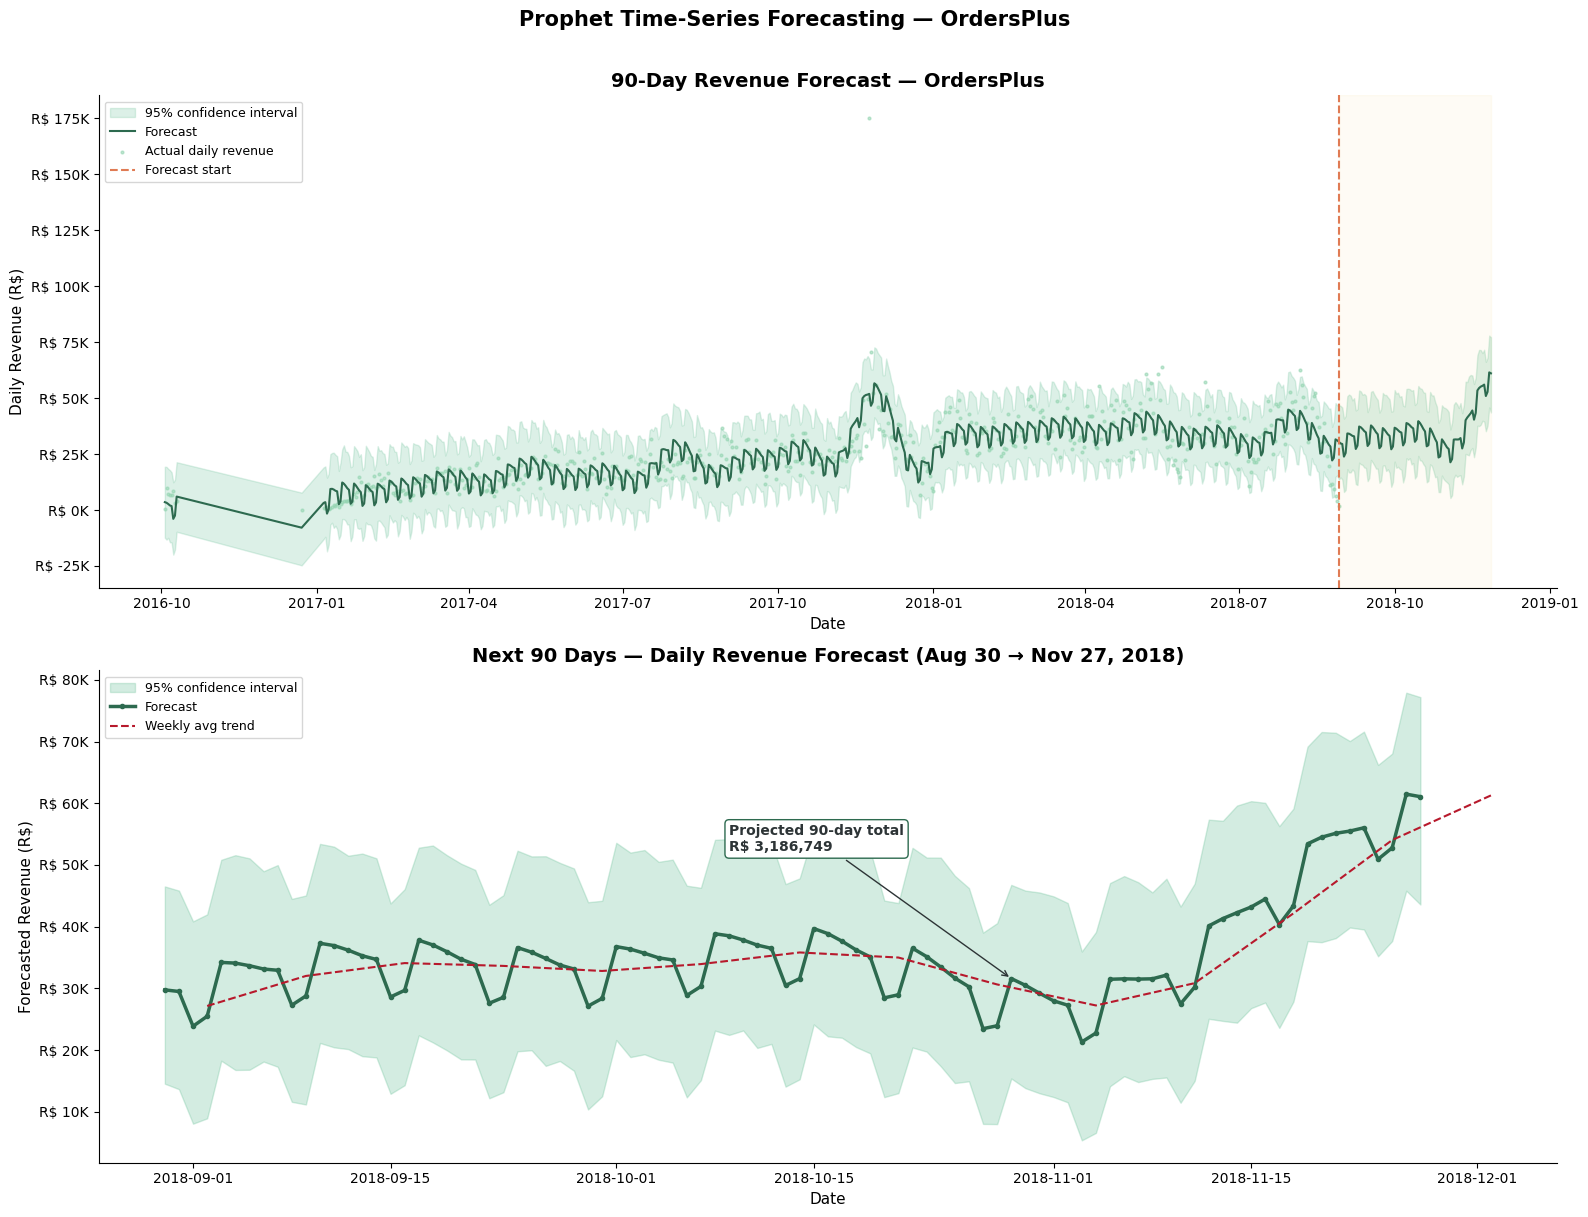

✓ Saved → docs/08_prophet_forecast.png


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ── Chart 1: Full forecast with actuals ───────────────────────
axes[0].fill_between(forecast["ds"],
                     forecast["yhat_lower"],
                     forecast["yhat_upper"],
                     alpha=0.2, color="#52B788",
                     label="95% confidence interval")
axes[0].plot(forecast["ds"], forecast["yhat"],
             color="#2D6A4F", linewidth=1.5, label="Forecast")
axes[0].scatter(daily["ds"], daily["y"],
                color="#95D5B2", s=4, alpha=0.6, label="Actual daily revenue")

# Shade forecast region
axes[0].axvspan(daily["ds"].max(), forecast["ds"].max(),
                alpha=0.05, color="#F6C243")
axes[0].axvline(daily["ds"].max(), color="#E07B54",
                linestyle="--", linewidth=1.5, label="Forecast start")

axes[0].set_title("90-Day Revenue Forecast — OrdersPlus")
axes[0].set_ylabel("Daily Revenue (R$)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"R$ {x/1000:.0f}K"))
axes[0].legend(fontsize=9)
axes[0].set_xlabel("Date")

# ── Chart 2: Forecast only — next 90 days ────────────────────
axes[1].fill_between(forecast_tail["ds"],
                     forecast_tail["yhat_lower"],
                     forecast_tail["yhat_upper"],
                     alpha=0.25, color="#52B788",
                     label="95% confidence interval")
axes[1].plot(forecast_tail["ds"], forecast_tail["yhat"],
             color="#2D6A4F", linewidth=2.5,
             marker="o", markersize=3, label="Forecast")

# Weekly average bands
weekly_avg = forecast_tail.resample("W", on="ds")["yhat"].mean()
axes[1].plot(weekly_avg.index, weekly_avg.values,
             color="#B7192C", linewidth=1.5,
             linestyle="--", label="Weekly avg trend")

axes[1].set_title("Next 90 Days — Daily Revenue Forecast (Aug 30 → Nov 27, 2018)")
axes[1].set_ylabel("Forecasted Revenue (R$)")
axes[1].set_xlabel("Date")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"R$ {x/1000:.0f}K"))
axes[1].legend(fontsize=9)

# Annotate total
axes[1].annotate(
    f"Projected 90-day total\nR$ {forecast_tail['yhat'].sum():,.0f}",
    xy=(forecast_tail["ds"].iloc[60], forecast_tail["yhat"].iloc[60]),
    xytext=(forecast_tail["ds"].iloc[40],
            forecast_tail["yhat"].max() * 0.85),
    arrowprops=dict(arrowstyle="->", color="#2D3436"),
    fontsize=10, fontweight="bold", color="#2D3436",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="#2D6A4F", linewidth=1)
)

plt.suptitle("Prophet Time-Series Forecasting — OrdersPlus",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("docs/08_prophet_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → docs/08_prophet_forecast.png")

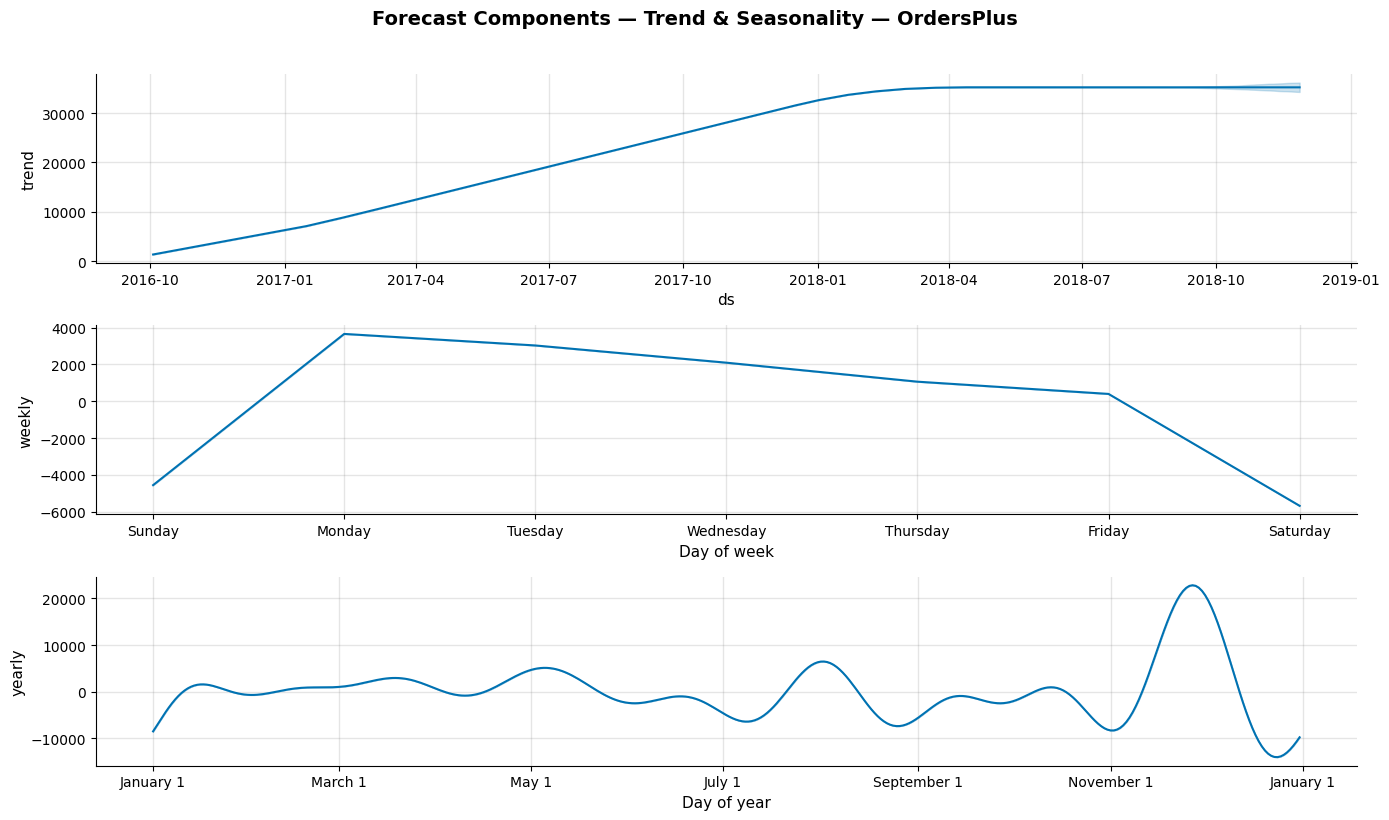

✓ Saved → docs/09_forecast_components.png


In [23]:
fig = model.plot_components(forecast)
fig.set_size_inches(14, 8)
fig.suptitle("Forecast Components — Trend & Seasonality — OrdersPlus",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("docs/09_forecast_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → docs/09_forecast_components.png")

In [24]:
print("=" * 55)
print("   OrdersPlus — EDA Complete — Key Findings")
print("=" * 55)
print(f"""
  BUSINESS HEALTH
  ├─ Total Revenue      : R$ 15,422,461
  ├─ Total Orders       : 96,477
  └─ Avg Order Value    : R$ 153.07

  DELIVERY PERFORMANCE
  ├─ Late delivery rate : 8.06% (8,125 orders)
  ├─ Worst state        : AL — 23.93% late
  └─ Best state         : RO — 2.88% late

  CUSTOMER EXPERIENCE
  ├─ On-time avg score  : 4.29 ★
  ├─ Late avg score     : 2.57 ★
  └─ Late → 1★ rate     : 46.2% of late orders

  CUSTOMER SEGMENTS (RFM)
  ├─ Champions          : 1,159  (highest value)
  ├─ Loyal Customers    : 36,312 (revenue backbone)
  ├─ At Risk            : 3,009  (R$ 439 avg — save them)
  └─ Lost               : 23,047 (never returned)

  RETENTION
  ├─ Avg retention rate : 8.02%
  └─ 92% of customers never make a 2nd purchase

  PAYMENT
  ├─ Credit card        : 78.3% of revenue
  └─ Avg installments   : 3.51 (credit card)

  FORECAST (next 90 days)
  ├─ Projected revenue  : R$ 3,186,749
  ├─ Lower bound        : R$ 1,737,942
  └─ Upper bound        : R$ 4,640,340
""")
print("=" * 55)
print("  Charts saved to docs/ folder")
print("  Next step: Streamlit dashboard")
print("=" * 55)

   OrdersPlus — EDA Complete — Key Findings

  BUSINESS HEALTH
  ├─ Total Revenue      : R$ 15,422,461
  ├─ Total Orders       : 96,477
  └─ Avg Order Value    : R$ 153.07

  DELIVERY PERFORMANCE
  ├─ Late delivery rate : 8.06% (8,125 orders)
  ├─ Worst state        : AL — 23.93% late
  └─ Best state         : RO — 2.88% late

  CUSTOMER EXPERIENCE
  ├─ On-time avg score  : 4.29 ★
  ├─ Late avg score     : 2.57 ★
  └─ Late → 1★ rate     : 46.2% of late orders

  CUSTOMER SEGMENTS (RFM)
  ├─ Champions          : 1,159  (highest value)
  ├─ Loyal Customers    : 36,312 (revenue backbone)
  ├─ At Risk            : 3,009  (R$ 439 avg — save them)
  └─ Lost               : 23,047 (never returned)

  RETENTION
  ├─ Avg retention rate : 8.02%
  └─ 92% of customers never make a 2nd purchase

  PAYMENT
  ├─ Credit card        : 78.3% of revenue
  └─ Avg installments   : 3.51 (credit card)

  FORECAST (next 90 days)
  ├─ Projected revenue  : R$ 3,186,749
  ├─ Lower bound        : R$ 1,737,942
  └